# 1. CNN WITH TENSORFLOW

In [11]:
# import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
print('Tensorflow version: ', tf.__version__)

import time

#import sklearn
#import os

Tensorflow version:  2.20.0


In [12]:
# measure the GPU performance in time

start = time.perf_counter()
print(f"Start time: {start:.4f} seconds")

Start time: 832.2304 seconds


In [13]:
# to make this notebook's output stable across runs
np.random.seed(42)
tf.random.set_seed(42)

# To plot pretty figures
# matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# A couple of utility functions to plot grayscale and RGB images
def plot_image(image):
    plt.imshow(image, cmap="gray", interpolation="nearest")
    plt.axis("off")

def plot_color_image(image):
    plt.imshow(image, interpolation="nearest")
    plt.axis("off")

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

In [14]:
# load fashion MIST in Keras, it is split in a train and a test set

fashion_mnist = keras.datasets.fashion_mnist

(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# look at fashion MNIST data shape
print (X_train_full.shape)
print (X_train_full.dtype)
print (X_test.shape)
print (X_test.dtype)
#print (X_test.head())

# split the full training set into a validation set and a smaller training set
# We also scale the pixel intensities down to the 0-1 range and convert them to floats, by dividing by 255.

X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.

(60000, 28, 28)
uint8
(10000, 28, 28)
uint8


In [15]:
type(y_train)

numpy.ndarray

In [16]:
# Prepare for Convolution2D input
X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-7
X_train = (X_train - X_mean) / X_std
X_valid = (X_valid - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

X_train = X_train[..., np.newaxis]
X_valid = X_valid[..., np.newaxis]
X_test = X_test[..., np.newaxis]

# look at fashion MNIST datashape after reshaping to 3D input tensors
print (X_train.shape)
print (X_valid.shape)
print (X_test.shape)

(55000, 28, 28, 1)
(5000, 28, 28, 1)
(10000, 28, 28, 1)


In [17]:
# the class names
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [18]:
# create a model: single stack of layers connected sequentially

from functools import partial

DefaultConv2D = partial(tf.keras.layers.Conv2D,
                        kernel_size=3, activation='relu', padding='same', kernel_initializer='he_normal')

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=[28, 28, 1]),
    DefaultConv2D(filters=64, kernel_size=7),
    tf.keras.layers.MaxPooling2D(pool_size=2),
    DefaultConv2D(filters=64, kernel_size=7, input_shape=[28, 28, 1]),
    tf.keras.layers.MaxPooling2D(pool_size=2),
    DefaultConv2D(filters=128),
    DefaultConv2D(filters=128),
    tf.keras.layers.MaxPooling2D(pool_size=2),
    DefaultConv2D(filters=256),
    DefaultConv2D(filters=256),
    tf.keras.layers.MaxPooling2D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=10, activation='softmax'),
])

# print model summary
print (model.summary())

keras.utils.plot_model(model, "my_mnist_model.png", show_shapes=True)

/home/robin/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 64)     │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 3, 3, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 3, 3, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,352,458 (5.16 MB)

 Trainable params: 1,352,458 (5.16 MB)

 Non-trainable params: 0 (0.00 B)

None
You must install pydot (`pip install pydot`) for `plot_model` to work.


In [19]:
# specify the loss function

model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])

In [20]:
# train the model with 10 epochs

history = model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.7498 - loss: 0.7366 - val_accuracy: 0.8606 - val_loss: 0.3931
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8500 - loss: 0.4583 - val_accuracy: 0.8624 - val_loss: 0.3699
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8666 - loss: 0.4108 - val_accuracy: 0.8812 - val_loss: 0.3363
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8761 - loss: 0.3666 - val_accuracy: 0.8838 - val_loss: 0.3222
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8838 - loss: 0.3446 - val_accuracy: 0.8874 - val_loss: 0.3271
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8902 - loss: 0.3263 - val_accuracy: 0.8930 - val_loss: 0.3484
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8940 - loss: 0.3200 - val_accuracy: 0.8850 - val_loss: 0.4171
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8940 - loss: 0.3134 -

{'verbose': 'auto', 'epochs': 10, 'steps': 1719}
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


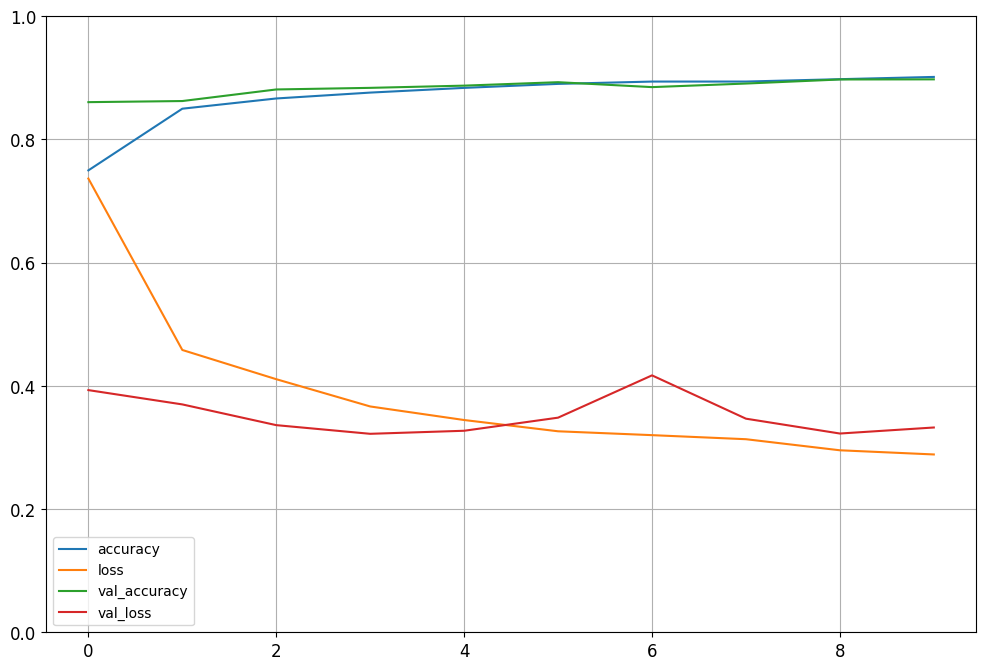

In [21]:
# print the history parameters

print (history.params)
print (history.epoch)
print (history.history.keys())

# show learning curves

pd.DataFrame(history.history).plot(figsize=(12, 8))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [22]:
# evaluate on the test set
score = model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8943 - loss: 0.3697


Print first 20 predictions on the test set with probability.

In [23]:
y_proba = model.predict(X_test)
print(y_proba[:20].round(2))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
[[0.   0.   0.   0.   0.   0.   0.   0.   0.   1.  ]
 [0.   0.   1.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   1.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   1.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.01 0.   0.03 0.   0.01 0.   0.94 0.   0.   0.  ]
 [0.   1.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   1.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   1.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   1.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   1.   0.   0.  ]
 [0.   0.   0.   0.   1.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   1.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.87 0.   0.06 0.06 0.02]
 [0.   0.   0.   1.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.02 0.   0.98 0.   0.   0.   0.   0.  ]
 [0.   1.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   1.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.09 0.   0.78 0.   0.13 0.   0.   0.  ]
 [0. 

Print first 20 prediction classes.

In [24]:
#define empty array
y_pred_class = np.zeros(y_proba.shape[0],dtype=np.int32)

#transfer y_pred matrix to y_pred array with class number only
for i in range(y_proba.shape[0]):
  highest_prob = 0
  class_highest = 0
  for j in range(y_proba.shape[1]):
    if y_proba[i, j] > highest_prob:
      highest_prob = y_proba[i, j]
      class_highest = j
  y_pred_class[i] = class_highest

print(y_pred_class[:20])

[9 2 1 1 6 1 4 6 5 7 4 5 5 3 4 1 2 4 8 0]


Compare actual test set labels with predictions.

In [25]:
print('First 20 actual values from the test set:\n', y_test[:20] )
print('First 20 predicted values from the test set:\n', y_pred_class[:20])

First 20 actual values from the test set:
 [9 2 1 1 6 1 4 6 5 7 4 5 7 3 4 1 2 4 8 0]
First 20 predicted values from the test set:
 [9 2 1 1 6 1 4 6 5 7 4 5 5 3 4 1 2 4 8 0]


Plot first 20 actual classes with images from the test set and compare with predicted values.

In [26]:
#reduce image shape from 3D to 2D dimensions
X_2D_image = np.squeeze(X_test, axis=3)
print(X_2D_image.shape)

(10000, 28, 28)


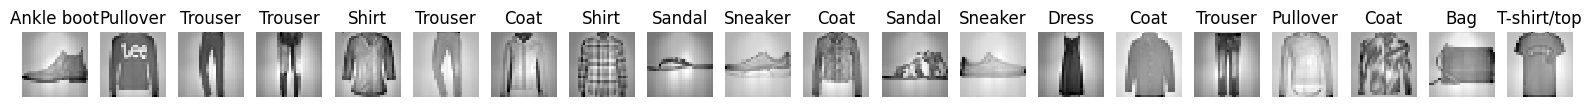

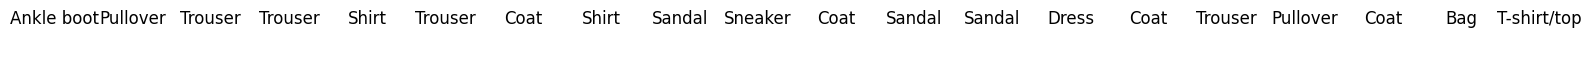

In [27]:
plt.figure(figsize=(20, 6))
for index, image in enumerate(X_2D_image[:20]):
    plt.subplot(1, 20, index + 1)
    plt.imshow(image, cmap="binary", interpolation="nearest")
    plt.axis('off')
    plt.title(class_names[y_test[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

plt.figure(figsize=(20, 0.2))
for index, image in enumerate(X_2D_image[:20]):
    plt.subplot(1, 20, index + 1)
    plt.axis('off')
    plt.title(class_names[y_pred_class[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

Let's show the confusion matrix: x-axis predicted labels, y-axis true labels

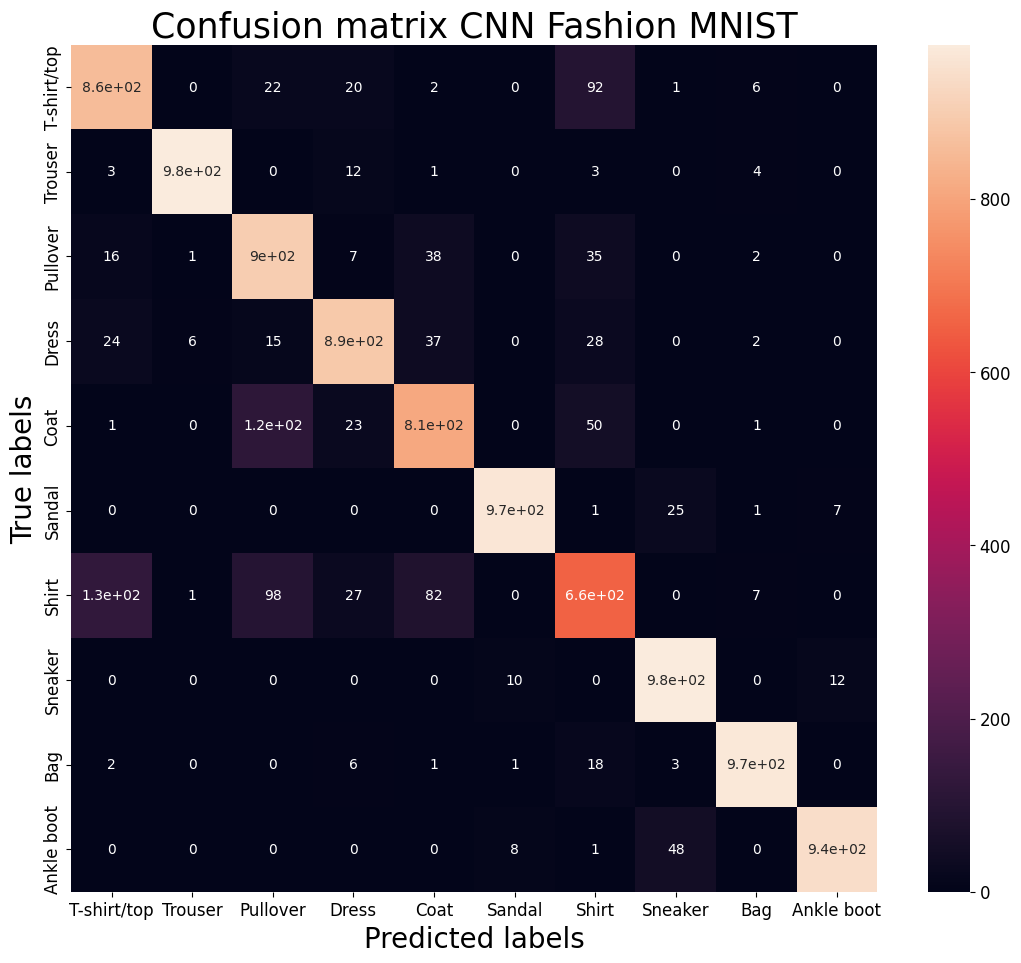

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize = (13, 11))
sns.heatmap(cm, xticklabels=class_names, yticklabels=class_names, annot = True)

plt.title("Confusion matrix CNN Fashion MNIST", fontsize = 25)
plt.xlabel("Predicted labels", fontsize = 20)
plt.ylabel("True labels", fontsize = 20)
plt.show()

In [29]:
# Measure the GPU performance

end = time.perf_counter()
print(f"Start time: {start:.4f} seconds")
print(f"End time: {end:.4f} seconds")
print(f"Elapsed time: {end - start:.4f} seconds")

Start time: 832.2304 seconds
End time: 930.3429 seconds
Elapsed time: 98.1126 seconds
